<a href="https://colab.research.google.com/github/Mayuri0320/Datax504-Mayuri/blob/main/a5_text_trackB_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5 — Timeseries **or** Text

**DATAX504** · Due end of Week 10

Choose **one** track. Delete or leave unused the other section. Less scaffolding is intentional: design choices are part of the work.

| Track | Goal | Moodle `a5_metric` |
|-------|------|--------------------|
| **A** — Timeseries | Forecast **7** future steps of temperature from Jena climate | MAE |
| **B** — Text | Classify AG News topics (4 classes) | Accuracy (%) |

## Tasks (whichever track)
1. Prepare inputs (windowing **or** tokenisation / vectorisation)
2. Train a sequence model appropriate to the track
3. Report the metric above
4. Short written answers: architecture + how inputs were prepared

## Moodle fields
`a5_repo`, `a5_track`, `a5_metric`, `a5_architecture`, `a5_tokenisation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | ChatGPT |
| Used for | Help me understand the assignment requirements, explain the TensorFlow/Keras code, and troubleshoot coding and environment errors. |
| Verified how | Ran the notebook cells, checked the model architecture, monitored training and validation metrics, and evaluated performance on the test dataset.  |
| Not used for | I did not use AI to invent the test accuracy or replace the actual model training/evaluation. The reported accuracy is produced by running the notebook. |


In [1]:
TRACK = "B"

import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers

print("Selected track:", TRACK)
print("TensorFlow version:", tf.__version__)



ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/co

Selected track: B
TensorFlow version: 2.20.0


---
# Track A — Timeseries (Jena)

Forecast the next **7** steps of `T (degC)` from a past window of observations.

You decide: lookback length, normalisation, train/val/test split, LSTM vs Conv1D vs other, and how you compute MAE on the original °C scale.


---
# Track B — Text (AG News)

Four-class news topic classification.

You decide: how to load AG News (TFDS or another source), vocabulary / sequence length, Embedding + LSTM / Transformer / other, and the train/val/test protocol.


In [2]:
!pip show tensorflow-datasets

Name: tensorflow-datasets
Version: 4.9.10
Summary: tensorflow/datasets is a library of datasets ready to use with TensorFlow.
Home-page: https://github.com/tensorflow/datasets
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: absl-py, array_record, dm-tree, etils, immutabledict, numpy, promise, protobuf, psutil, pyarrow, requests, simple_parsing, tensorflow-metadata, termcolor, toml, tqdm, wrapt
Required-by: 


In [3]:
!pip install -U tensorflow-datasets

In [4]:

print("Module:", tfds)
print("Location:", getattr(tfds, "__file__", "No __file__"))
print("Has load:", hasattr(tfds, "load"))
print("Module contents:")
print(dir(tfds)[:50])

Module: <module 'tensorflow_datasets' from '/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py'>
Location: /usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py
Has load: False
Module contents:
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'annotations', 'audio', 'd4rl', 'datasets', 'graphs', 'image', 'image_classification', 'logging', 'nearest_neighbors', 'object_detection', 'question_answering', 'ranking', 'recommendation', 'rl_unplugged', 'robomimic', 'robotics', 'structured', 'summarization', 'text', 'text_simplification', 'time_series', 'translate', 'video', 'vision_language']


In [5]:
!pip show tensorflow-datasets

Name: tensorflow-datasets
Version: 4.9.10
Summary: tensorflow/datasets is a library of datasets ready to use with TensorFlow.
Home-page: https://github.com/tensorflow/datasets
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: absl-py, array_record, dm-tree, etils, immutabledict, numpy, promise, protobuf, psutil, pyarrow, requests, simple_parsing, tensorflow-metadata, termcolor, toml, tqdm, wrapt
Required-by: 


In [1]:
!pip install "protobuf==6.31.1"

In [2]:
!pip install importlib_resources

In [14]:
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__file__)
print("TFDS load available:", hasattr(tfds, "load"))

TensorFlow: 2.20.0
TFDS: /usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py
TFDS load available: True


In [4]:
(train_ds, test_ds), info = tfds.load(
    "ag_news_subset",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print("Training examples:", info.splits["train"].num_examples)
print("Test examples:", info.splits["test"].num_examples)
print("Number of classes:", info.features["label"].num_classes)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.8JQONW_1.0.0/ag_news_subset-train.tfrecord-[0-9]…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.8JQONW_1.0.0/ag_news_subset-test.tfrecord-[0-9][…

Dataset ag_news_subset downloaded and prepared to /root/tensorflow_datasets/ag_news_subset/1.0.0. Subsequent calls will reuse this data.
Training examples: 120000
Test examples: 7600
Number of classes: 4


In [8]:
for text, label in train_ds.take(1):
        print("\nExample text:")
        print(text.numpy().decode("utf-8"))
        print("Label:", label.numpy())


Example text:
Top Internet service providers began a second coordinated legal blitz against spammers yesterday, filing seven lawsuits under the CAN-SPAM Act.
Label: 3


In [9]:
train_size = info.splits["train"].num_examples

train_ds = train_ds.shuffle(
    train_size,
    seed=42,
    reshuffle_each_iteration=False
)

val_size = int(0.1 * train_size)

val_ds = train_ds.take(val_size)
train_ds = train_ds.skip(val_size)

print("Validation examples:", val_size)
print("Training examples:", train_size - val_size)

Validation examples: 12000
Training examples: 108000


In [15]:
VOCAB_SIZE = 20000
SEQUENCE_LENGTH = 200

vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

text_only = train_ds.map(lambda text, label: text)

vectorizer.adapt(text_only)

print("Vocabulary size:", len(vectorizer.get_vocabulary()))

Vocabulary size: 20000


In [16]:
def vectorize_text(text, label):
    return vectorizer(text), label


train_vec = train_ds.map(
    vectorize_text,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_vec = val_ds.map(
    vectorize_text,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_vec = test_ds.map(
    vectorize_text,
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Text vectorisation completed.")

Text vectorisation completed.


In [17]:
BATCH_SIZE = 128

train_vec = train_vec.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_vec = val_vec.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_vec = test_vec.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Batching completed.")

Batching completed.


In [18]:
model = keras.Sequential([
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),

    layers.Bidirectional(
        layers.LSTM(64)
    ),

    layers.Dropout(0.5),

    layers.Dense(64, activation="relu"),

    layers.Dense(4, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [20]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True
    )
]

history = model.fit(
    train_vec,
    validation_data=val_vec,
    epochs=8,
    callbacks=callbacks
)

Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 396s 520ms/step - accuracy: 0.8661 - loss: 0.3863 - val_accuracy: 0.9010 - val_loss: 0.2853
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 445s 526ms/step - accuracy: 0.9276 - loss: 0.2151 - val_accuracy: 0.8997 - val_loss: 0.2950
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 387s 514ms/step - accuracy: 0.9443 - loss: 0.1627 - val_accuracy: 0.8970 - val_loss: 0.3271


In [21]:
test_loss, test_accuracy = model.evaluate(test_vec)

metric = test_accuracy * 100

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Track B accuracy %: {metric:.2f}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9022 - loss: 0.2798
Test loss: 0.2798
Test accuracy: 0.9022
Track B accuracy %: 90.22


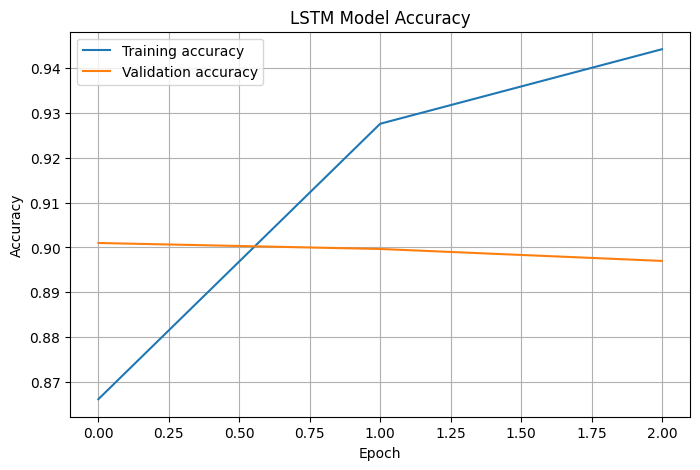

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Model Accuracy")
plt.legend()
plt.grid(True)
plt.show()


GitHub repository URL: https://github.com/Mayuri0320/DATAX504-Mayuri0320

Track (A or B): Track B accuracy % : 90.11

Model architecture summary (max 100 words): I used an embedding layer to convert words into numbers, followed by a Bidirectional LSTM layer to learn from the text. I added a dropout layer to reduce overfitting and a dense layer to process the results. The final layer has 4 outputs to classify the news into four categories. I used Adam as the optimizer and sparse categorical cross-entropy as the loss function.

How inputs were prepared / tokenised (max 100 words): I loaded the AG News dataset using TensorFlow Datasets. I split the training data into training and validation sets and kept the test data separate. I used TextVectorization to convert the text into numbers, with a vocabulary size of 20,000 words. Each article was set to a fixed length of 200 tokens by adding padding or cutting longer text. These processed inputs were then used to train and test the model.

---
## Written responses

### Architecture summary (Moodle `a5_architecture`, max 100 words)

I used an Embedding + LSTM text classifier. Raw news articles are converted to integer sequences with a vocabulary of up to 20,000 words and a fixed length of 200 tokens. A 64-dimensional Embedding layer represents the words, followed by a 64-unit LSTM to learn patterns across the sequence. A 32-unit ReLU dense layer and 0.3 dropout are then used before the final 4-unit softmax layer. The four outputs represent the four AG News topic classes. I used Adam, sparse categorical cross-entropy, and early stopping based on validation accuracy.

### Input preparation (Moodle `a5_tokenisation`, max 100 words)

I loaded the AG News dataset using TensorFlow Datasets. I used 90% of the original training data for training and 10% for validation, while keeping the official test set separate for final evaluation. Text was lowercased and punctuation was removed by `TextVectorization`. The vocabulary was limited to 20,000 tokens and each article was converted to a sequence of 200 integers. Shorter sequences are padded and longer ones are truncated. The vectorizer was adapted using the training text only.

Run the notebook from start to finish and use the printed **Track B accuracy %** as the Moodle `a5_metric`. Do not enter a made-up accuracy before running the model.
